In [10]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

caminho_atual = Path.cwd()

if caminho_atual.name == "notebooks":
    raiz_projeto = caminho_atual.parent
else:
    raiz_projeto = caminho_atual

pasta_dataset = raiz_projeto / "dataset" / "original" / "Dataset"
pasta_resultados = raiz_projeto / "resultados"
pasta_resultados.mkdir(exist_ok=True)
print("Dataset:", pasta_dataset)

Dataset: /home/bruno/Desktop/processamento-de-imagens/dataset/original/Dataset


In [ ]:
IMAGE_SIZE = (512, 512)
GAUSSIAN_BLUR_KERNEL = (5, 5)
SOBEL_KSIZE = 3
SEGMENTATION_THRESHOLD = 60
MORPH_KERNEL = (3, 3)
ERODE_ITER = 1
DILATE_ITER = 2
MIN_CONTOUR_AREA = 100

In [ ]:
def listar_imagens_raw(pasta_dataset):
    return sorted(list(pasta_dataset.rglob("*_RAW.jpg")))

def encontrar_mascara_lane(pasta_caso):
    mascara_lane = list(pasta_caso.glob("*_LANE.png"))
    if not mascara_lane:
        raise Exception("Máscara LANE não encontrada")
    return mascara_lane[0]

def carregar_e_redimensionar(caminho, modo=cv2.IMREAD_COLOR, tamanho=IMAGE_SIZE):
    img = cv2.imread(str(caminho), modo)
    img = cv2.resize(img, tamanho)
    return img

def aplicar_mascara(imagem, mascara):
    return cv2.bitwise_and(imagem, imagem, mask=mascara)

def preprocessar(imagem_pista):
    cinza = cv2.cvtColor(imagem_pista, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(cinza, GAUSSIAN_BLUR_KERNEL, 0)
    equalizada = cv2.equalizeHist(blur)
    return cinza, blur, equalizada

def aplicar_sobel(equalizada):
    sobel_x = cv2.Sobel(equalizada, cv2.CV_64F, 1, 0, ksize=SOBEL_KSIZE)
    sobel_y = cv2.Sobel(equalizada, cv2.CV_64F, 0, 1, ksize=SOBEL_KSIZE)
    sobel = cv2.magnitude(sobel_x, sobel_y)
    sobel = cv2.convertScaleAbs(sobel)
    return sobel

def segmentar(sobel):
    _, binaria = cv2.threshold(sobel, SEGMENTATION_THRESHOLD, 255, cv2.THRESH_BINARY)
    kernel = np.ones(MORPH_KERNEL, np.uint8)
    erosao = cv2.erode(binaria, kernel, iterations=ERODE_ITER)
    dilatacao = cv2.dilate(erosao, kernel, iterations=DILATE_ITER)
    return binaria, erosao, dilatacao

def detectar_regioes(dilatacao, imagem_original):
    contornos, _ = cv2.findContours(dilatacao, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    resultado = imagem_original.copy()
    quantidade = 0
    
    for contorno in contornos:
        area = cv2.contourArea(contorno)
        if area > MIN_CONTOUR_AREA:
            x,y,w,h = cv2.boundingRect(contorno)
            cv2.rectangle(resultado, (x,y), (x+w,y+h), (0,0,255), 2)
            quantidade += 1
    
    return resultado, quantidade

Funções modulares para processamento de imagens

Selecionando imagem

In [12]:
imagens_raw = listar_imagens_raw(pasta_dataset)
print("Total:", len(imagens_raw))
caminho_imagem = imagens_raw[0]
print(caminho_imagem.name)

Total: 2235
1007599_RS_386_386RS289112_28920_RAW.jpg


Encontrando máscara da pista

In [13]:
pasta_caso = caminho_imagem.parent
mascara_lane = encontrar_mascara_lane(pasta_caso)
print(mascara_lane.name)

1007599_RS_386_386RS289112_28920_LANE.png


Aplicando máscara da pista

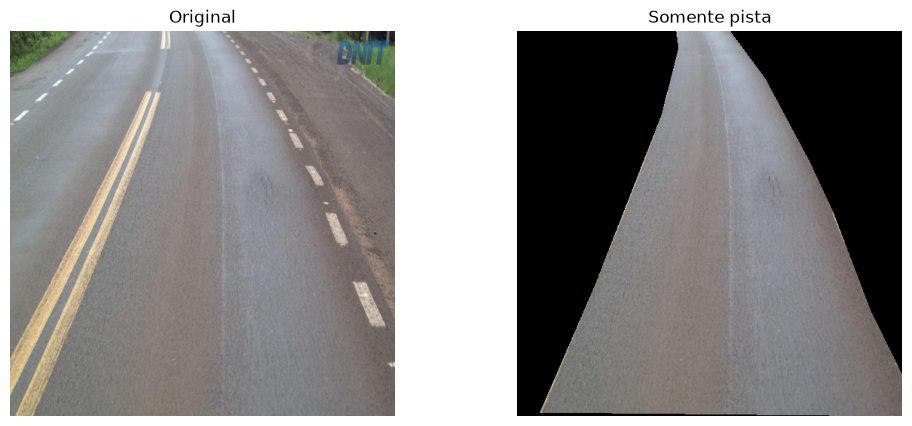

In [14]:
imagem = carregar_e_redimensionar(caminho_imagem)
lane = carregar_e_redimensionar(mascara_lane, cv2.IMREAD_GRAYSCALE)

imagem_pista = aplicar_mascara(imagem, lane)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(imagem_pista, cv2.COLOR_BGR2RGB))
plt.title("Somente pista")
plt.axis("off")
plt.show()

Pré-processamento

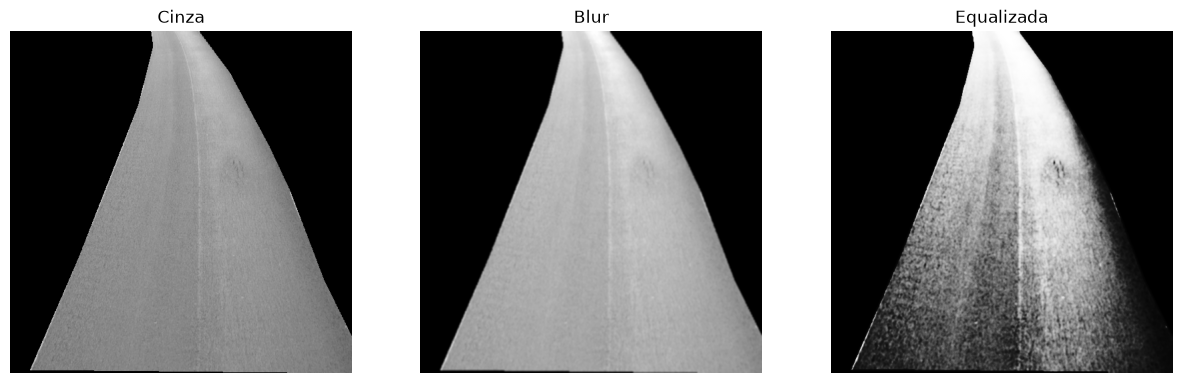

In [15]:
cinza, blur, equalizada = preprocessar(imagem_pista)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(cinza,cmap="gray")
plt.title("Cinza")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(blur,cmap="gray")
plt.title("Blur")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(equalizada,cmap="gray")
plt.title("Equalizada")
plt.axis("off")
plt.show()

Sobel (filtro passa-alta)

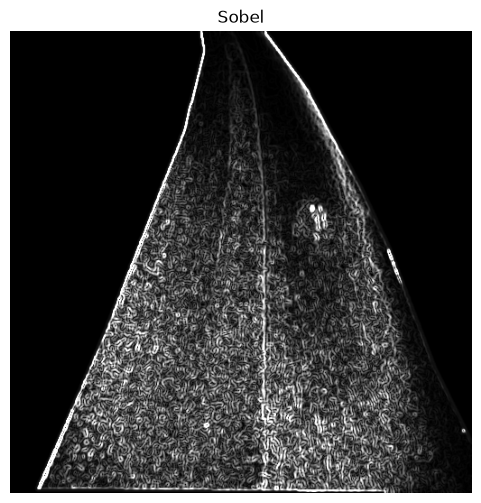

In [16]:
sobel = aplicar_sobel(equalizada)

plt.figure(figsize=(6,6))
plt.imshow(sobel,cmap="gray")
plt.title("Sobel")
plt.axis("off")
plt.show()

Limiarização e morfologia

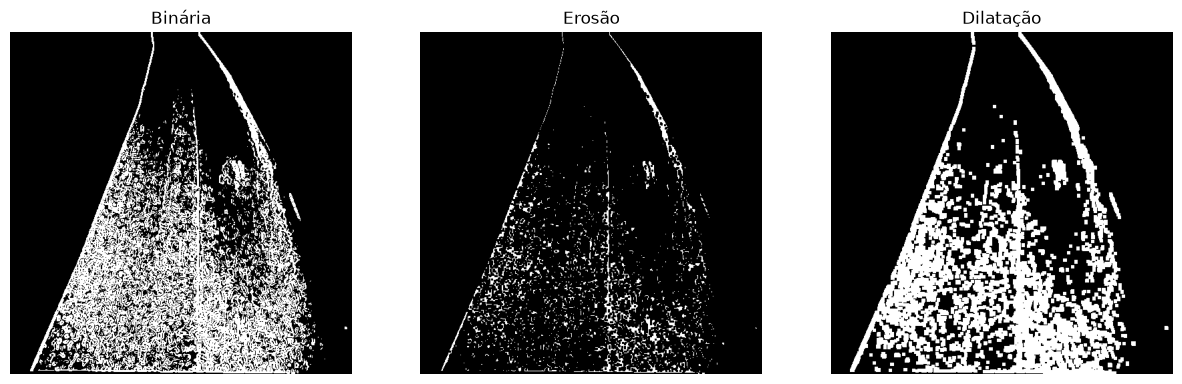

In [17]:
binaria, erosao, dilatacao = segmentar(sobel)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(binaria,cmap="gray")
plt.title("Binária")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(erosao,cmap="gray")
plt.title("Erosão")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(dilatacao,cmap="gray")
plt.title("Dilatação")
plt.axis("off")
plt.show()

Detectando e marcando regiões

Regiões suspeitas: 17


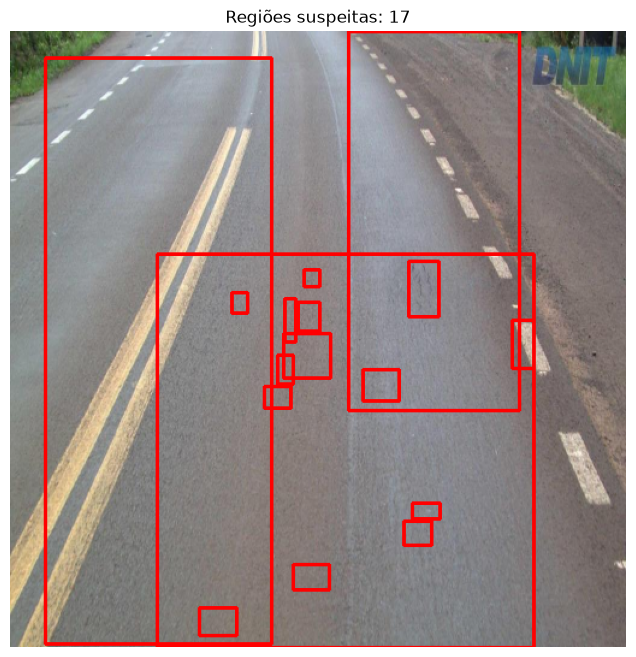

In [18]:
resultado, quantidade = detectar_regioes(dilatacao, imagem)

print(f"Regiões suspeitas: {quantidade}")
resultado_rgb = cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.imshow(resultado_rgb)
plt.title(f"Regiões suspeitas: {quantidade}")
plt.axis("off")
plt.show()